<h1 align="center">PROJET QI 2025 - 2026</h1>

<h2 align="center">Probabilité d'extinction d'espèces dans un système proie-prédateur</h2>

<h3 align="center">Par SIDIBE Kassim-Junior, AKNOUCH Hocine,  SOW Thierno Djiby & Maxime Nicolino</h3>

##  Rapport du projet

#### Paramètres du modèle

- **u(t)** : population de proies  
- **v(t)** : population de prédateurs  

- **a** : paramètre influençant la croissance des proies et la réponse des prédateurs  
- **b** : seuil d’Allee (niveau minimal de proies pour éviter l’extinction)  
- **m** : intensité de l’interaction proie–prédateur  
- **d** : taux de mortalité des prédateurs  

- **f(u)** : fonction de croissance des proies  
- **g(u)** : fonction de réponse des prédateurs  

- **$\lambda$** : seuil lié à l’équilibre du système  
- **$\bar \lambda$** : seuil de changement de stabilité  

- **u₀** : population initiale de proies  
- **v₀** : population initiale de prédateurs  

- **$t_∞$** : temps final d’observation  
- **ε** : seuil définissant l’extinction

In [1]:
# Importation des modules importants
import openturns as ot
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

### 1)

In [2]:
# Valeurs nominales
a_nom = 0.8
b_nom = 0.1
d_nom = 7.5
m_nom = 14.25

# Calcul de lambda
lambda_nom = (a_nom * d_nom) / (m_nom - d_nom)

# Calcul de lambda barre
lambda_bar = (b_nom + 1 - a_nom + np.sqrt((b_nom + 1 - a_nom)**2 + 3*(a_nom*b_nom + a_nom - b_nom))) / 3

print("lambda_nom =", lambda_nom)
print("lambda_bar_nom =", lambda_bar)


lambda_nom = 0.8888888888888888
lambda_bar_nom = 0.6196152422706632


# 1. Évolution des trajectoires en fonction de $v_0$

L'évolution du système dépend de manière critique de la densité initiale de prédateurs, créant un phénomène de **seuil de survie** dû à l'**effet Allee fort** chez la proie.

### Région de sur-exploitation (Extinction)

Si la densité initiale de prédateurs $v_0$ est trop élevée, les prédateurs consomment la proie plus vite qu'elle ne peut se multiplier pour compenser l'effet Allee.

Dans ce cas, les trajectoires convergent vers l'équilibre $((0,0))$, entraînant **l'extinction globale des deux espèces**.

### Région de coexistence (Invasion réussie)

Si $v_0$ est suffisamment faible (et que la population de proies est au-dessus du **seuil de survie $b$**, le prédateur peut s'établir.

La trajectoire peut alors mener à :

- Un **équilibre de coexistence stable** $C$ où les deux populations se stabilisent.
- Un **cycle limite** (oscillations périodiques).

### Seuil critique

Il existe une **courbe seuil unique** (liée à la valeur de bifurcation ( $\lambda^{*}$) qui sépare mathématiquement les conditions initiales menant à **l'extinction** de celles menant à **la coexistence**.

---

# 2. Possibilité d'un cycle limite

Oui, l'existence d'un **cycle limite** est formellement démontrée dans ce modèle pour certaines plages de paramètres.

### Origine

Le cycle limite naît d'une **bifurcation de Hopf** à partir de l'équilibre de coexistence ($C$).

Cette bifurcation est généralement **supercritique**, ce qui signifie que le cycle est **stable** et attire les trajectoires proches.

### Unicité et stabilité

Sous certaines conditions mathématiques (notamment sur la forme des fonctions de croissance et de réponse fonctionnelle), le système possède **un cycle limite unique et stable**.

### Disparition du cycle

Lorsque le paramètre de mortalité du prédateur $\lambda$ diminue vers une valeur critique \( $\lambda^{*}$ \), la **période du cycle augmente** jusqu'à devenir **infinie**.

Le cycle disparaît alors en se transformant en **boucle hétéroclinique** reliant les points d'équilibre de la proie seule.

## Un cycle limite est-il possible ?

Oui, un **cycle limite** est possible dans ce modèle.

Cela signifie que les populations de proies et de prédateurs peuvent **osciller de manière régulière dans le temps** au lieu de se stabiliser à une valeur fixe. Par exemple, la population de proies augmente, ce qui permet aux prédateurs de se multiplier. Ensuite, l’augmentation des prédateurs fait diminuer le nombre de proies, ce qui entraîne à son tour une baisse des prédateurs. Ce phénomène se répète alors périodiquement.

Ce comportement apparaît pour **certaines valeurs des paramètres du modèle**. Dans ces conditions, les oscillations sont **stables**, c’est-à-dire que les trajectoires du système finissent par suivre ce cycle régulier.

Cependant, si certains paramètres changent (par exemple la mortalité des prédateurs), ces oscillations peuvent **disparaître** et le système peut alors évoluer vers un autre type de comportement, comme un équilibre ou l’extinction d’une des espèces.

### 2)

In [3]:
variables =["t" , "u" , "v" , "a" , "b" , "d" , "m"]
formules = ["(m*u/(a+u)) * ( ((a+u)*(1-u)*(u-b))/(b*m) - v )", "v*((m*u/(a+u))-d)"]

flot = ot.SymbolicFunction(variables, formules)

u0=1
v0=0.1
flot_nom=flot([0 , u0 , v0 ,a_nom , b_nom , d_nom , m_nom])
print("le flot à l'état nominal est " , flot_nom )

le flot à l'état nominal est  [-0.791667,0.0416667]


### 3)

In [4]:
flotParam= ot.ParametricFunction(flot,[3 , 4 , 5, 6] , [a_nom, b_nom, d_nom, m_nom])
print(flotParam([0 , 1 , 0.1]))

[-0.791667,0.0416667]


### 4)

In [5]:
Phi=ot.ParametricFunction(flotParam , [0] , [0] )
print(Phi([1,0.1]))

[-0.791667,0.0416667]


### 5)

In [6]:
solver = ot.Fehlberg(Phi)

##  Code de production de la figure (3)

In [7]:
import openturns.viewer as otv

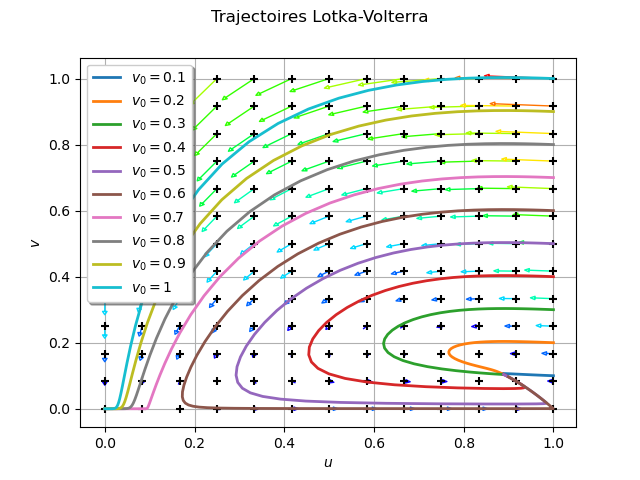

In [8]:
Tinf=20
N_T=100

n_T = 100
grille = [Tinf * (i / (N_T- 1))**3 for i in range(n_T)]
# Maillage pour afficher le champ de vecteurs
maillage = ot.IntervalMesher([12]*2).build(ot.Interval([0.0] * 2, [1.0] * 2))
points = maillage.getVertices()
champ = ot.Field(maillage, Phi(points))
ot.ResourceMap.SetAsScalar("Field-ArrowScaling", 1.0)
g = champ.draw()
g.setTitle("Trajectoires Lotka-Volterra")
g.setXTitle(r'$u$')
g.setYTitle(r'$v$')
g.setLegendPosition("topleft")
nuage = ot.Cloud(points)
nuage.setColor("black")
g.add(nuage)
# Un ensemble de trajectoires
palette = ot.Drawable.BuildDefaultPalette(10)
for i in range(10):
    v_0 = 0.1 + 0.1 * i
    uv = solver.solve([1, v_0], grille)
    trajectoire = ot.Curve(uv)
    trajectoire.setLineWidth(2)
    trajectoire.setColor(palette[i])
    trajectoire.setLegend(rf"$v_0=${v_0:<.1g}")
    g.add(trajectoire)
view = otv.View(g, (800, 600), square_axes=True)
#view.save("Figures/ODELotkaVolterra.pdf")
view.close()
# Pour afficher la figure dans une cellule de notebook
g
# Pour produire le fichier PDF contenant la figure
# view=otv.View(g,(800,600),square_axes=True)
# view.save(r"C:\Users\tsow2\OneDrive\Bureau\Mathapp\QI\Projet\figures\ODELotkaVolterra.pdf")
# view.close()

### 6)

In [26]:
def ProiePredateurPy(parametres):

    v0, a, b, d, m = parametres
    u0 = 1.0  # valeur initiale de la proie

    # Définit le flot symbolique avec toutes les variables
    variables = ["t", "u", "v", "a", "b", "d", "m"]
    formules = ["(m*u/(a+u))*((a+u)*(1-u)*(u-b)-v)",
                "v*((m*u/(a+u))-d)"]
    
    flot = ot.SymbolicFunction(variables, formules)

    # Crée la fonction paramétrique en fixant les paramètres a,b,d,m
    flotParam = ot.ParametricFunction(flot, [3, 4, 5, 6], [a, b, d, m])

    # Fixe le temps t = 0
    Phi = ot.ParametricFunction(flotParam, [0], [0])

    # État initial : uniquement variables d’état
    Y0 = [u0, v0]

    # Grille de temps non uniforme (commence à 0)
    Tinf = 20
    N_T = 100
    timeGrid = [Tinf * (i / (N_T-1))**3 for i in range(N_T)]

    # Résolution du système
    solver = ot.Fehlberg(Phi)
    result = solver.solve(Y0, timeGrid)

    # Retourner uniquement l'état final [u(t_inf), v(t_inf)]
    return result[-1]


## Modélisation probabiliste du système autour de son état nominal

### 7) Création des distributions et graphes

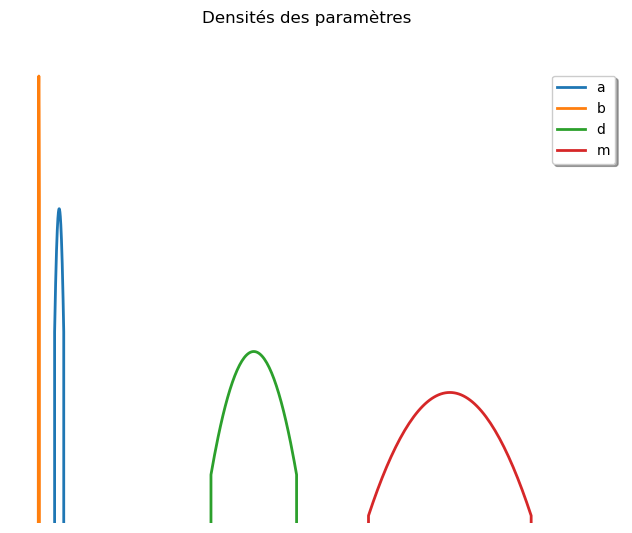

In [27]:
# écart-type
sigma_a = a_nom / 10
sigma_b = b_nom / 10
sigma_d = d_nom / 10
sigma_m = m_nom / 10

# bornes des lois tronquées
a_min = a_nom - 2*sigma_a
a_max = a_nom + 2*sigma_a

b_min = b_nom - 2*sigma_b
b_max = b_nom + 2*sigma_b

d_min = d_nom - 2*sigma_d
d_max = d_nom + 2*sigma_d

m_min = m_nom - 2*sigma_m
m_max = m_nom + 2*sigma_m

# distributions tronquées
aDist = ot.TruncatedDistribution(ot.Normal(a_nom, sigma_a), a_min, a_max)
bDist = ot.TruncatedDistribution(ot.Normal(b_nom, sigma_b), b_min, b_max)
dDist = ot.TruncatedDistribution(ot.Normal(d_nom, sigma_d), d_min, d_max)
mDist = ot.TruncatedDistribution(ot.Normal(m_nom, sigma_m), m_min, m_max)

# Drawables
drawables = [aDist.drawPDF(), bDist.drawPDF(), dDist.drawPDF(), mDist.drawPDF()]

# Ajouter les légendes correspondantes
legendes = ["a", "b", "d", "m"]
for d, l in zip(drawables, legendes):
    d.setLegends(l)

# Graph
g = ot.Graph()
g.setTitle("Densités des paramètres")
g.setXTitle("Valeurs")
g.setYTitle("Densité")
g.setLogScale(ot.GraphImplementation.LOGY)
g.setColors(ot.Drawable.BuildDefaultPalette(len(drawables)))  # couleurs différentes
g.setLegendPosition("topright")

# Ajouter les drawables
for d in drawables:
    g.add(d)

# Affichage
view = otv.View(g, (800,600))
view.show()

### 7) Montrons que presque surement m>d

**Première approche** :

Cette approche repose sur la simulation par *Monte-Carlo*. Ce qui consiste à générer une grande d'échantillons des variables $m$ et $d$ et observer leurs comportements l'un par rapport à l'autre.

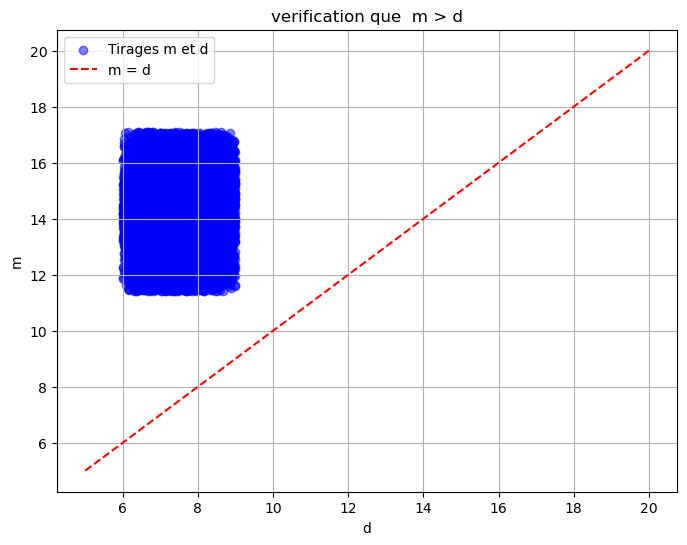

In [28]:
# Tirages aléatoires
N = 20000
d_samples = dDist.getSample(N)
m_samples = mDist.getSample(N)

# Extraire les valeurs
d_vals = [d_samples[i,0] for i in range(N)]
m_vals = [m_samples[i,0] for i in range(N)]

plt.figure(figsize=(8,6))
plt.scatter(d_vals, m_vals, color='blue', alpha=0.5, label="Tirages m et d")
plt.plot([5,20],[5,20], 'r--', label="m = d")  # diagonale pour référence
plt.xlabel("d")
plt.ylabel("m")
plt.title("verification que  m > d")
plt.legend()
plt.grid(True)
plt.show()

**Une seconde approche** : 

Pour d :

    μd​=7,5

    σd​=0,75 (soit 10% de μd​)

    dmax​=μd​+2σd​=7,5+1,5=9,0

Pour m :

    μm​=14,25

    σm​=1,425

    mmin​=μm​−2σm​=14,25−2,85=11,4

la condition m>d est toujours respectée.

### 8)

$\lambda = \frac{ad}{m-d} = \frac{a}{\frac{m}{d}-1}$. De plus les variables $a,d$ et $m$ sont mutullement indépendantes.

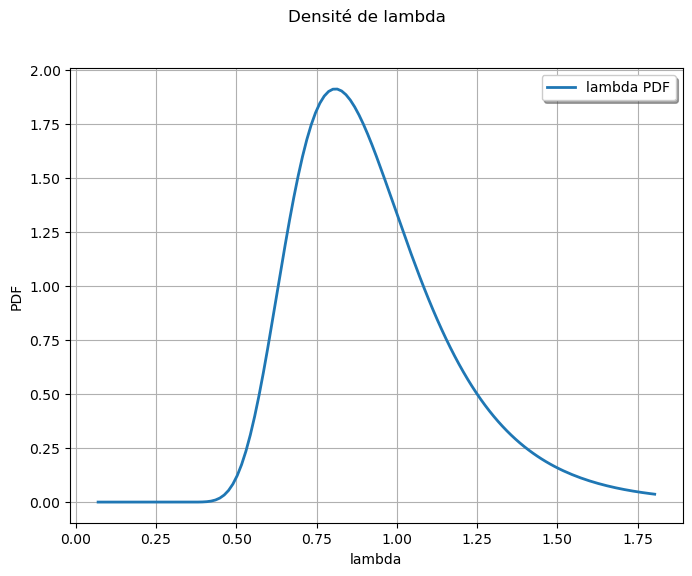

In [29]:
lambdaDist = aDist * dDist / (mDist - dDist)
lambdaDist.setDescription(["lambda"])
graph_lambda = lambdaDist.drawPDF()
graph_lambda.setTitle("Densité de lambda")

view = otv.View(graph_lambda, (800,600))
view.show()

In [30]:
print("Moyenne de lambda =", lambdaDist.getMean()[0])
print("Ecart-type de lambda =", lambdaDist.getStandardDeviation()[0])

Moyenne de lambda = 0.9334159505792161
Ecart-type de lambda = 0.2521931936279904


L'arithmétique des distributions n'est pas applicable à $\bar \lambda$.

### 9)

Minimum de b - lambda : -2.978361621296943


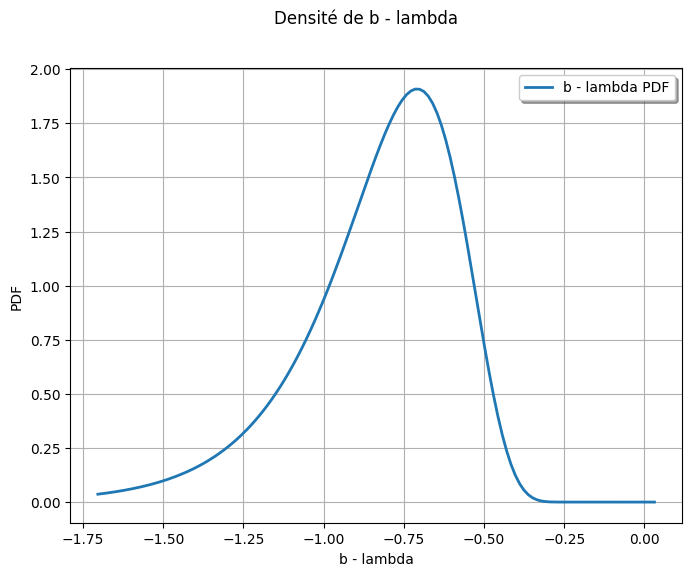

In [26]:
diff1 = bDist - lambdaDist
diff1.setDescription(["b - lambda"])
print("Minimum de b - lambda :", diff1.getRange().getLowerBound()[0])
graph = diff1.drawPDF()
graph.setTitle("Densité de b - lambda")
view = otv.View(graph, (800,600))
view.show()

On trouve que le minimum de b-$\lambda$ est négative . C'est à dire qu'on  a sur un ensemble de mesure non nulle que b<$\lambda$. On conclue donc qu'on a pas presque surement b>$\lambda$.

In [28]:
diff2 = bDist - lambdaDist/4
diff2.setDescription(["b - lambda/4"])
prob = 1 - diff2.computeCDF(0)

print("P(b > lambda/4) =", prob)

P(b > lambda/4) = 0.0001025760241953888


On pourrait utiliser la méthode **SORM** pour déterminer cette probabilité car l'événement est rare.

### 10)

In [33]:
v0Dist =ot.Uniform(0.1 , 0.5)
v0Dist.setDescription(["v0"])

parametresDist = ot.ComposedDistribution([v0Dist, aDist, bDist, dDist, mDist])
parametresDist.setDescription(["v0","a","b","d","m"])
interval, prob =parametresDist.computeBilateralConfidenceIntervalWithMarginalProbability(0.99)
print("Intervalle de confiance bilatéral (0.99) :")
print(interval,'\n')
print("Probabilité marginale correspondante :", prob)


Intervalle de confiance bilatéral (0.99) :
[0.100402, 0.499598]
[0.641395, 0.958605]
[0.0801744, 0.119826]
[6.01308, 8.98692]
[11.4249, 17.0751] 

Probabilité marginale correspondante : 0.9979919516614765


### 11)

In [34]:
parametresRV =ot.RandomVector(parametresDist)
normeCarree =ot.SymbolicFunction(["u","v"], ["u^2 + v^2"])
fonctionUV = ot.PythonFunction(5, 2, ProiePredateurPy)
fonctionLimite = ot.ComposedFunction(normeCarree, fonctionUV)
normeCarreeRV = ot.CompositeRandomVector(fonctionLimite, parametresRV)

### 12)

In [35]:
# Fixer la graine
ot.RandomGenerator.SetSeed(2026)

# Générer un échantillon de taille 400
sample = normeCarreeRV.getSample(400)

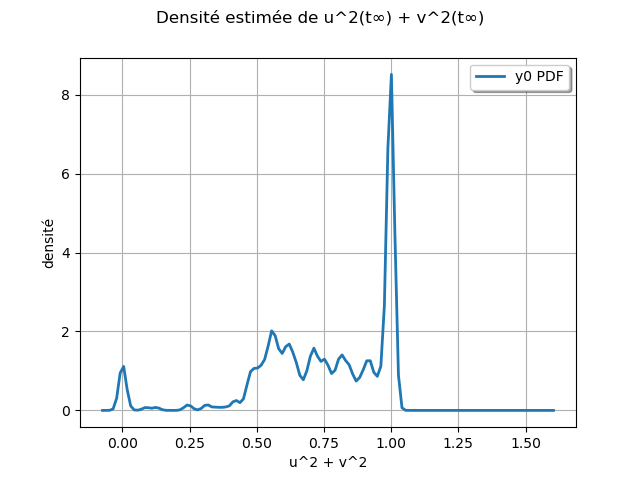

In [37]:
# Reconstruction par noyaux
ks = ot.KernelSmoothing()
loiReconstruite = ks.build(sample)

# Tracé de la densité
graph = loiReconstruite.drawPDF()
graph.setTitle("Densité estimée de u^2(t∞) + v^2(t∞)")
graph.setXTitle("u^2 + v^2")
graph.setYTitle("densité")

graph

On constate qu'il y'a des norme inférieure à 0 alors que la norme étant supérieure à 0. Par conséquent, on doit faire une correction de bord.

La méthode qui sera utilisée est celle du **mirroring**.  

Nombre de points reflétés : 9


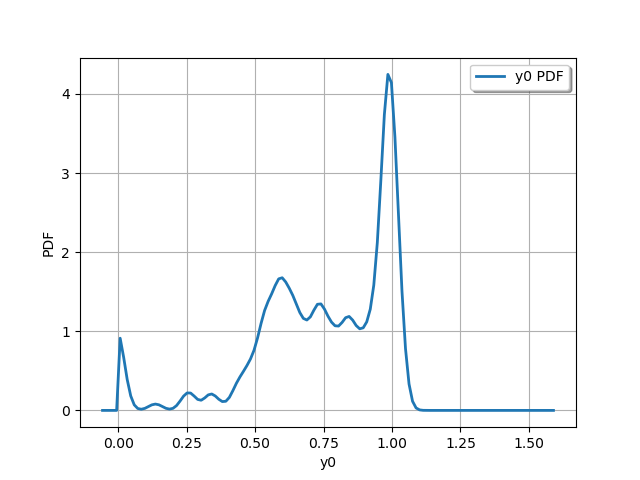

In [179]:
# 1. Échantillon initial
sample = loiReconstruite.getSample(400)
h = ot.KernelSmoothing().computeMixedBandwidth(sample)

# 2. Symétrisation manuelle : on filtre les points proches de 0 (entre 0 et h)
BordSample = [x for x in sample if 0 <= x[0] < h[0]]
print("Nombre de points reflétés :", len(BordSample))

# Création des points miroirs
# On crée un nouvel échantillon pour ne pas polluer l'original
augmented_sample = ot.Sample(sample) 
for x in BordSample:
    augmented_sample.add([-x[0]])

# 3. Construction du KernelSmoothing
ks = ot.KernelSmoothing()

# On construit la distribution sur l'échantillon augmenté
dist_temp = ks.build(augmented_sample, h)

# 4. Troncature et Redressement (IMPORTANT)
# On définit l'intervalle réel [0, +inf[
interval = ot.Interval([0.0001], [ot.SpecFunc.MaxScalar], [True], [False])

# On utilise la distribution tronquée qui recalcule la constante 
# pour que l'intégrale sur [0, inf] soit égale à 1
loiReconstruite_2 = ot.TruncatedDistribution(dist_temp, interval)

# 5. Visualisation
graph = loiReconstruite_2.drawPDF()
# On affiche l'échantillon ORIGINAL (pas l'augmenté) pour vérifier l'ajustement
graph

In [192]:
epsilon = 1e-3
# événement extinction
seuil = epsilon**2
# Calcul de la probabilité que normeCarreeRV < seuil
proba_extinction = loiReconstruite_2.computeCDF(seuil)

print("Probabilité d'extinction (norme^2 < seuil) :", proba_extinction)

Probabilité d'extinction (norme^2 < seuil) : 0.0


Avec la valeur de $v_0$ qui est entre 0.1 et 0.5  , en utilisant la courbe de la question 5) , Il est tout à fait logique que la probabilité d'extinction soit extrêmement faible avec les paramètres suivant les lois definis mais **non nul**. Cette valeur n'est donc pas crédible.

### 13)

In [194]:
epsilon = 1e-3
# événement extinction
seuil = epsilon**2
event = ot.ThresholdEvent(normeCarreeRV, ot.Less(), seuil)

In [195]:
# algorithme SubsetSampling
algo = ot.SubsetSampling(event)
# coefficient de variation maximum
algo.setMaximumCoefficientOfVariation(0.1)
# exécution

algo.run()

# résultats

result = algo.getResult()

print("Probabilité d'extinction :", result.getProbabilityEstimate())
print("Coefficient de variation :", result.getCoefficientOfVariation())
print("Nombre d'itérations :", result.getOuterSampling())

Probabilité d'extinction : 0.04949000000000004
Coefficient de variation : 0.02370271309354955
Nombre d'itérations : 20000


La méthode de **Subset Sampling** fournit une estimation de la probabilité d’extinction avec une très faible variance relative, comme en témoigne le coefficient de variation largement inférieur au seuil fixé ($0.1$).

Cependant, cette précision élevée est obtenue **au prix d’un coût computationnel important ($20000$ simulations)**.

D’un point de vue méthodologique, Subset Sampling est particulièrement adapté aux événements rares, car il repose sur une décomposition en événements intermédiaires conditionnels.

Or ici, la probabilité d’extinction est de l’ordre de $10^{−2}$, ce qui correspond à un événement modérément probable.

### 14)

In [196]:
sequence = ot.SobolSequence()

experiment = ot.LowDiscrepancyExperiment(sequence, parametresDist, 1)

algo = ot.ProbabilitySimulationAlgorithm(event, experiment)

# coefficient de variation max
algo.setMaximumCoefficientOfVariation(0.1)

# nombre maximum d'itérations
algo.setMaximumOuterSampling(20000)

# exécution
algo.run()

In [197]:
result = algo.getResult()

print("Probabilité d'extinction :", result.getProbabilityEstimate())
print("Coefficient de variation :", result.getCoefficientOfVariation())
print("Nombre d'itérations :", result.getOuterSampling())

Probabilité d'extinction : 0.047197640117994114
Coefficient de variation : 0.09962441759982464
Nombre d'itérations : 2034


L’utilisation d’une séquence de Sobol (méthode quasi-Monte Carlo) permet d’obtenir une estimation de la probabilité avec un nombre d’évaluations significativement réduit.

Le coefficient de variation est proche du seuil fixé ($0.1$), ce qui indique que :

l’algorithme s’arrête dès que le critère de précision est atteint
l’estimation est acceptable mais moins précise que celle obtenue avec Subset Sampling

La faible taille d’échantillon ($≈2000$) met en évidence l’efficacité des séquences à faible discrépance pour réduire la variance par rapport à un Monte Carlo classique.

**Choix de la meilleur approche**

La méthode **quasi-Monte Carlo** basée sur une séquence de **Sobol** est la plus adaptée dans ce contexte. En effet, compte tenu du fait que l’événement étudié **n’est pas rare** et que la précision obtenue par la méthode de **Sobol** satisfait le critère imposé, **cette dernière offre le meilleur compromis entre coût de calcul et précision**. Elle permet d’obtenir une estimation fiable de la probabilité d’extinction avec un coût computationnel réduit, contrairement à Subset Sampling qui apparaît ici **surdimensionnée**.


# IV) Modélisation probabiliste du système autour d'un état perturbé

### 15)

In [198]:
# valeurs nominales
b_nom = 0.3
m_nom = 9.5

# écarts-types
sigma_b = 0.1 * b_nom
sigma_m = 0.1 * m_nom

# bornes des lois tronquées
b_min = b_nom - 2*sigma_b
b_max = b_nom + 2*sigma_b

m_min = m_nom - 2*sigma_m
m_max = m_nom + 2*sigma_m

# Lois des paramètres
b = ot.TruncatedNormal(b_nom, sigma_b, b_min, b_max)
b.setDescription(['b'])

m = ot.TruncatedNormal(m_nom, sigma_m, m_min, m_max)
m.setDescription(['m'])

In [199]:
bDist = ot.TruncatedDistribution(ot.Normal(b_nom, sigma_b), b_nom-2*sigma_b, b_nom+2*sigma_b)
mDist = ot.TruncatedDistribution(ot.Normal(m_nom, sigma_m), m_nom-2*sigma_m, m_nom+2*sigma_m)

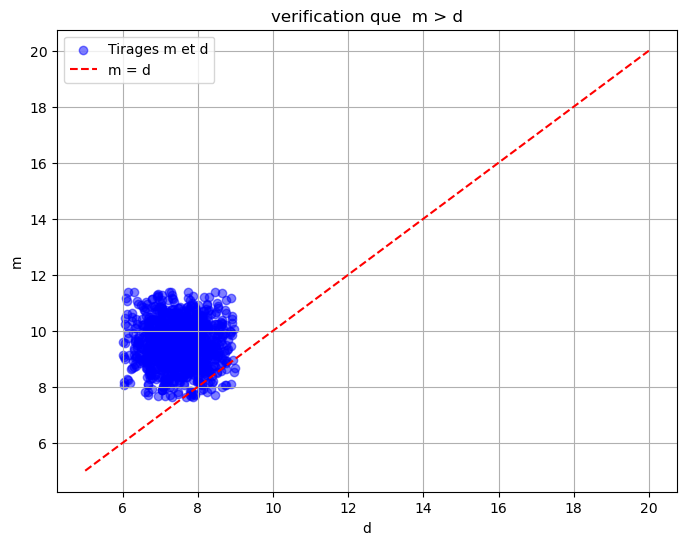

In [201]:
# Tirages aléatoires
N = 1000
d_samples = dDist.getSample(N)
m_samples = mDist.getSample(N)

# Extraire les valeurs
d_vals = [d_samples[i,0] for i in range(N)]
m_vals = [m_samples[i,0] for i in range(N)]


plt.figure(figsize=(8,6))
plt.scatter(d_vals, m_vals, color='blue', alpha=0.5, label="Tirages m et d")
plt.plot([5,20],[5,20], 'r--', label="m = d")
plt.xlabel("d")
plt.ylabel("m")
plt.title("verification que  m > d")
plt.legend()
plt.grid(True)
plt.show()

On observe que **l'évenement m>d n'est plus presque sûr**.

### 16)

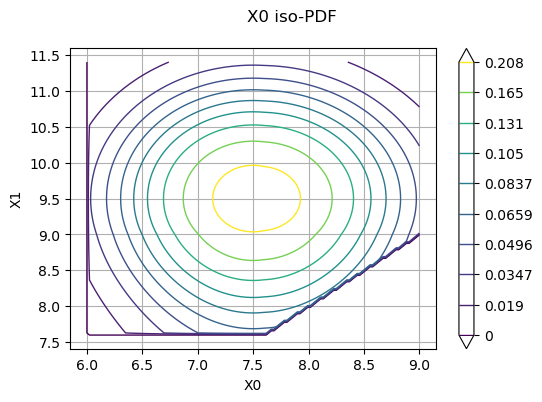

In [202]:
# vecteur des distributions marginales
marginals = [dDist, mDist]

# loi jointe
joint_dm = ot.MaximumEntropyOrderStatisticsDistribution(marginals)

# Tracer la densité
graph = joint_dm.drawPDF()
view = otv.View(graph, (600, 400))
#view.setTitle("Densité jointe de (d,m) avec m > d")
view.show()

### 17)

In [203]:
# distribution complète avec indépendance des autres paramètres
parametresDist = ot.BlockIndependentDistribution([v0Dist, aDist, bDist, joint_dm])

interval, prob =parametresDist.computeBilateralConfidenceIntervalWithMarginalProbability(0.99)
print("Intervalle de confiance bilatéral (0.99) :")
print(interval)
print("Probabilité marginale correspondante :", prob)

Intervalle de confiance bilatéral (0.99) :
[0.100402, 0.499598]
[0.641396, 0.958604]
[0.240523, 0.359477]
[6.01308, 8.98692]
[7.61657, 11.3834]
Probabilité marginale correspondante : 0.9979915685181937


On remarque que les intervalles de confiance  de b et m ont changé  , tandis que les autres paramètres conservent leurs intervalles de confiance par rapport au cas nominal .
0.9979915685181937 est la probabilité marginale , c'est à dire la probabilité que tous les paramètres soient compris dans les intervalles respectifs indiqués ici .

### 18)

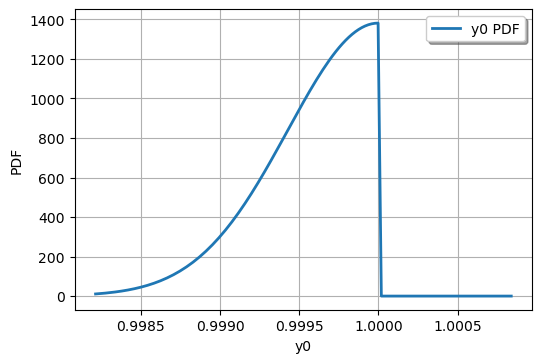

In [212]:
# rédefinition de la fonctyion norme au carrée
parametresRV = ot.RandomVector(parametresDist)
normeCarree = ot.SymbolicFunction(["u","v"], ["u^2 + v^2"])
fonctionUV = ot.PythonFunction(5, 2, ProiePredateurPy)
fonctionLimite = ot.ComposedFunction(normeCarree, fonctionUV)
normeCarreeRV = ot.CompositeRandomVector(fonctionLimite, parametresRV)

# graine aléatoire
ot.RandomGenerator.SetSeed(2026)

# échantillon
sample = normeCarreeRV.getSample(400)

# reconstruction à noyau
kde = ot.KernelSmoothing()
density = kde.build(sample)
densityGraphBounded = ot.TruncatedDistribution(density, 0.0, 1.0)

# tracer la densité
graph = densityGraphBounded.drawPDF()
view = otv.View(graph, (600,400))
view.show()

Vu l'échantillon , nous pensons qu'il y'a pas besoins de refaire une reconstruction à noyaux .

### 19)

In [213]:
# événement extinction
epsilon = 1e-3
seuil = epsilon**2
event = ot.ThresholdEvent(normeCarreeRV, ot.Less(), seuil)

# échantillonneur Monte Carlo
experiment=ot.MonteCarloExperiment(parametresDist, 1)

# algorithme de simulation
algo = ot.ProbabilitySimulationAlgorithm(event, experiment)
algo.setMaximumCoefficientOfVariation(0.1)
algo.setMaximumOuterSampling(20000)

# exécution
algo.run()

# résultats
result = algo.getResult()
print("Probabilité d'extinction :", result.getProbabilityEstimate())
print("Coefficient de variation :", result.getCoefficientOfVariation())
print("Nombre d'itérations :", result.getOuterSampling())

Probabilité d'extinction : 0.0030999999999999956
Coefficient de variation : 0.12680312400751262
Nombre d'itérations : 20000


1. **Analyse**
- Faible probabilité d’extinction\
L’événement est très rare (<0.5%)
- Coefficient de variation élevé (0.127) met en évidence un dépassement du seuil de précision acceptable pour des probabilités rares (<0.1 recommandé).
Cela indique une incertitude élevée sur l’estimation malgré 20000 tirages.
- Coût computationnel élevé : **20000 simulations** du modèle pour un résultat **peu précis**. Cela traduit une **faible efficacité**.

La pertubation induit donc une imprécision quant à la determination de la probabilité d'extinction.

2. **Conclusion** 
La méthode Monte Carlo standard permet d’obtenir une estimation brute de la probabilité d’extinction, mais elle souffre de faible précision et coût élevé pour des événements rares.

Pour améliorer la fiabilité et réduire le coût, il est souhaitable de recourir à des méthodes spécialisées pour événements rares, comme :

- Subset Sampling (méthode adaptative, meilleure convergence pour rare events)
- Quasi-Monte Carlo (séquences quasi-aléatoires, réduction de la variance)
- Importance Sampling (rééchantillonnage pondéré autour des régions critiques)

***Bonus***

In [214]:
# algorithme SubsetSampling
algo = ot.SubsetSampling(event)
# coefficient de variation maximum
algo.setMaximumCoefficientOfVariation(0.1)
# exécution
algo.run()

# résultats

result = algo.getResult()

print("Probabilité d'extinction :", result.getProbabilityEstimate())
print("Coefficient de variation :", result.getCoefficientOfVariation())
print("Nombre d'itérations :", result.getOuterSampling())


Probabilité d'extinction : 0.002938000000000002
Coefficient de variation : 0.07057369773811495
Nombre d'itérations : 30000


La probabilité d'extinction diminue drastiquement par rapport à celle de l'état nominal. 
Ce résultat est tout à fait logique. En effet, malgré le durcissement des conditions de survie des proies, la dimunition de m qui correspond à l'intensité d'interaction entre les proies et les prédateurs favorise la pérénité du système proie-prédacteur.